## Grade Prediction (Linear Regression)

In [2]:
import pandas as pd

dataframe = pd.read_csv('/home/jm/.cache/kagglehub/datasets/samira1992/student-grades-intermediate-dataset/versions/1/Student_Grades.csv')

dataframe.head()

,Hours,Practice,TeamWork,MidTerm,FinalExam,Scores,Grade
0,2.5,0.5,0.0,2,2.3,21,C
1,5.1,1.5,0.5,4,4.9,47,B
2,3.2,1.0,0.5,3,2.9,27,C
3,8.5,3.7,1.2,7,7.7,75,A
4,3.5,1.2,0.3,3,3.2,30,C


In [4]:
print("Dataset shape:", dataframe.shape)
print("Columns:", dataframe.columns.tolist())
print("First 5 rows:\n", dataframe.head())
print("Missing values:\n", dataframe.isnull().sum())
print("Data types:\n", dataframe.dtypes)

Dataset shape: (25, 7)
Columns: ['Hours', 'Practice', 'TeamWork', 'MidTerm', 'FinalExam', 'Scores', 'Grade']
First 5 rows:
    Hours  Practice  TeamWork  MidTerm  FinalExam  Scores Grade
0    2.5       0.5       0.0        2        2.3      21     C
1    5.1       1.5       0.5        4        4.9      47     B
2    3.2       1.0       0.5        3        2.9      27     C
3    8.5       3.7       1.2        7        7.7      75     A
4    3.5       1.2       0.3        3        3.2      30     C
Missing values:
 Hours        0
Practice     0
TeamWork     0
MidTerm      0
FinalExam    0
Scores       0
Grade        0
dtype: int64
Data types:
 Hours        float64
Practice     float64
TeamWork     float64
MidTerm        int64
FinalExam    float64
Scores         int64
Grade         object
dtype: object


In [10]:
dataframe.drop(['Grade'], axis=1, inplace=True)

In [11]:
dataframe.describe()

,Hours,Practice,TeamWork,MidTerm,FinalExam,Scores
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,5.012000,2.760000,1.812000,4.920000,5.348000,51.480000
std,2.525094,1.722885,1.697871,2.325941,2.528689,25.286887
min,1.100000,0.200000,0.000000,2.000000,1.900000,17.000000
25%,2.700000,1.500000,0.500000,3.000000,3.200000,30.000000
50%,4.800000,2.500000,1.200000,4.000000,4.900000,47.000000
75%,7.400000,3.700000,3.000000,7.000000,7.700000,75.000000
max,9.200000,6.200000,6.000000,9.000000,9.700000,95.000000


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

sns.set_style('whitegrid')

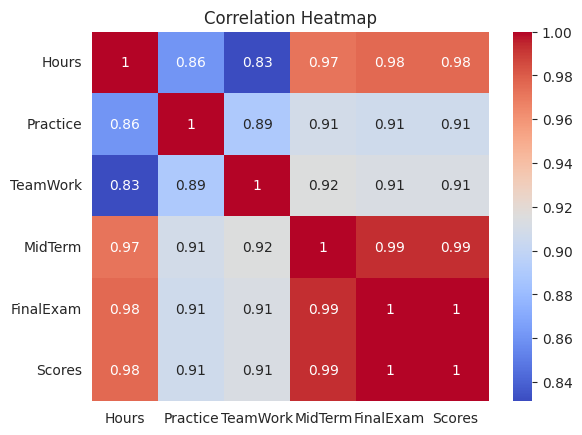

In [13]:
sns.heatmap(dataframe.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

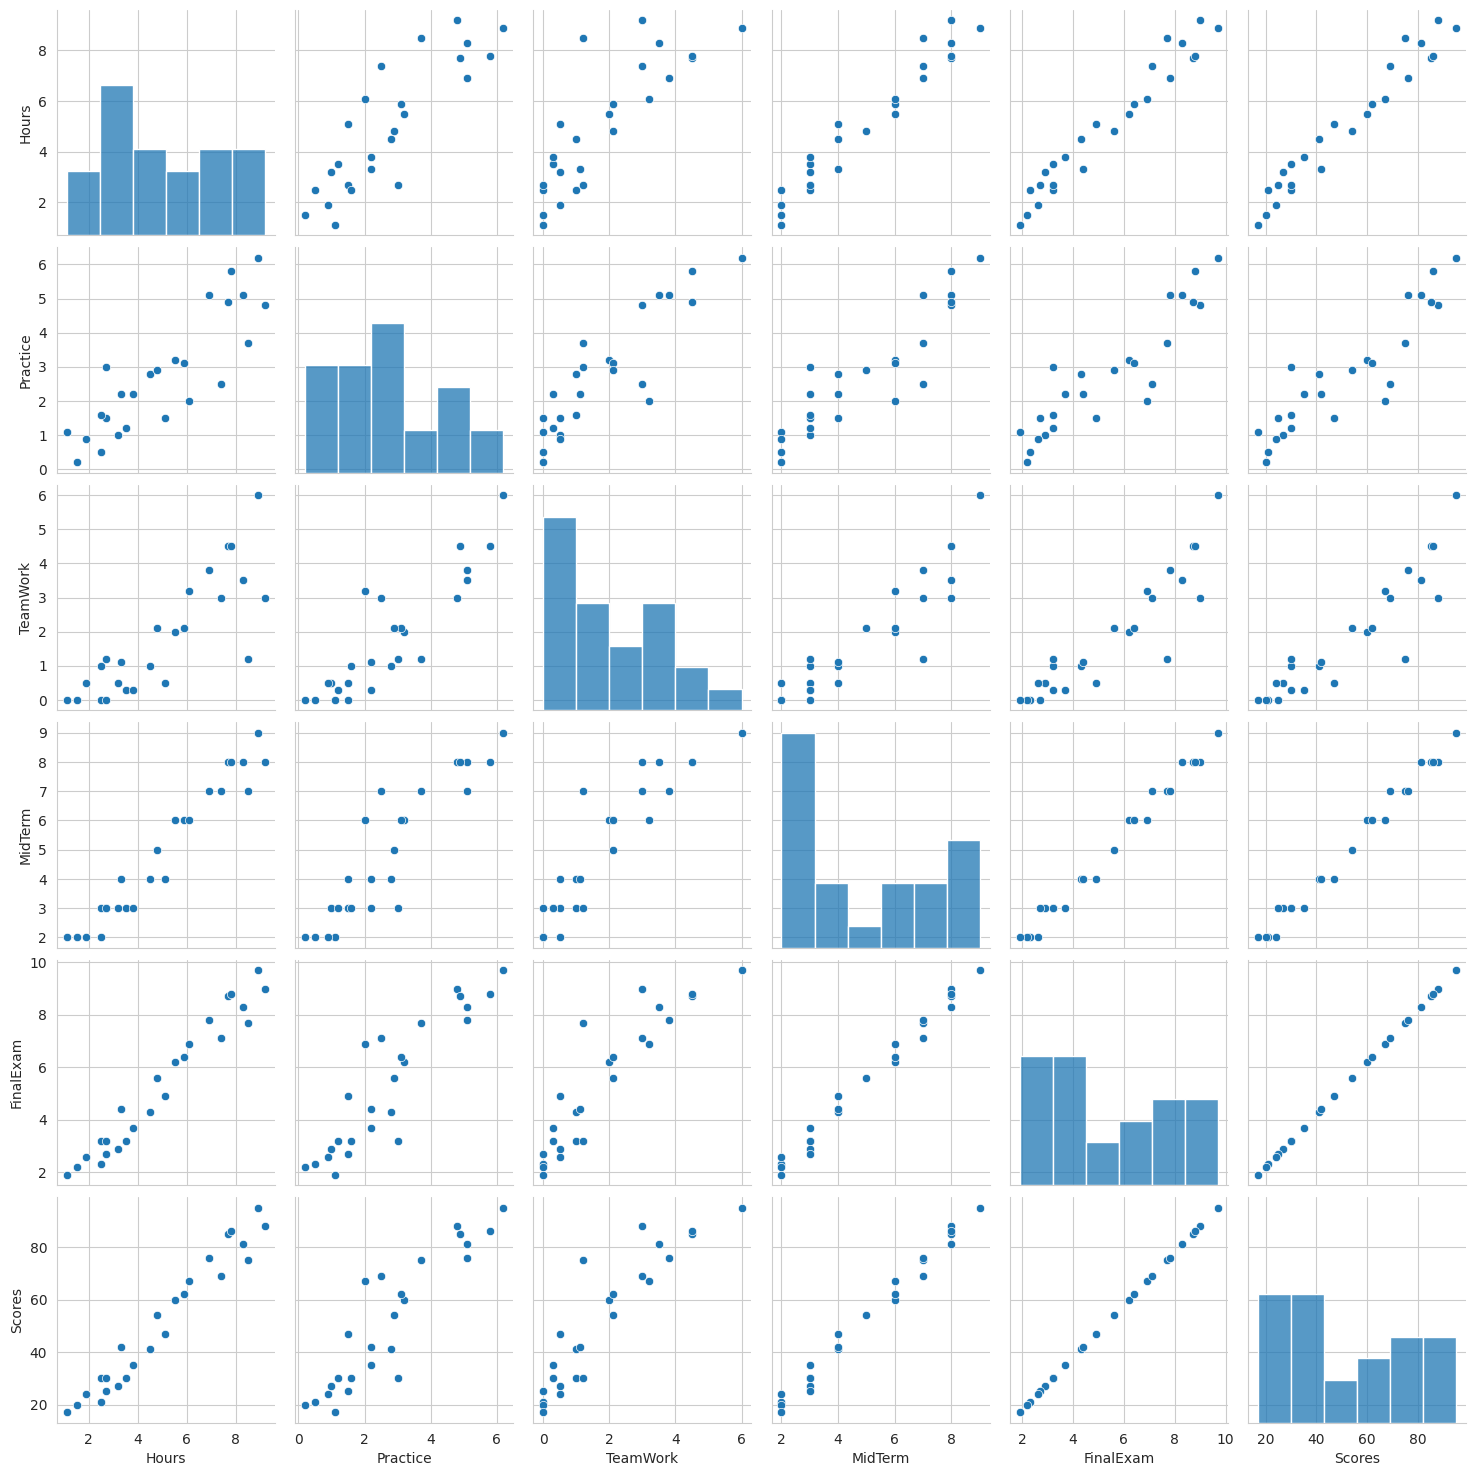

In [14]:
sns.pairplot(dataframe)

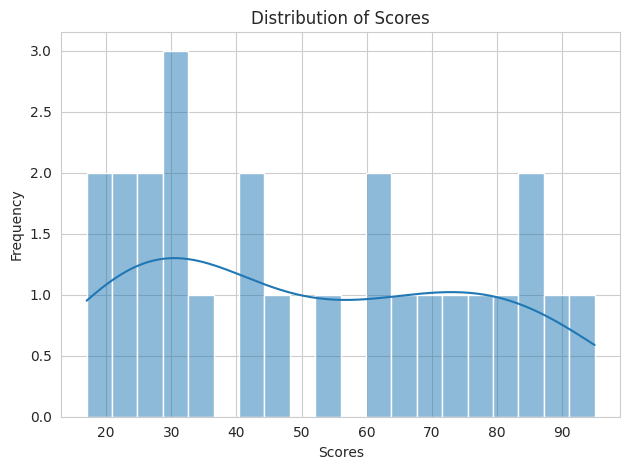

In [16]:
sns.histplot(dataframe['Scores'], bins=20, kde=True)
plt.title('Distribution of Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [17]:
# Splitting the data into features and target variable
X = dataframe.drop('Scores', axis=1) # Features
y = dataframe['Scores'] # Target variable

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Creating the model
model = LinearRegression()

In [20]:
from sklearn.preprocessing import MinMaxScaler
# Feature Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
# Get model intercepts and coefficients
intercept = model.intercept_
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

print("Model Intercept:", intercept)
print("Model Coefficients:")
print(coefficients)

Model Intercept: 16.999999999999993
Model Coefficients:
            Coefficient
Hours      3.569103e-14
Practice  -7.105427e-15
TeamWork   3.552714e-14
MidTerm   -1.065814e-14
FinalExam  7.800000e+01


In [25]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)
# Make predictions on the testing set
y_test_pred = model.predict(X_test)

In [26]:
# Create a DataFrame to compare actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print(comparison_df.head())

    Actual  Predicted
5       20       20.0
1       47       47.0
13      42       42.0
2       27       27.0
12      41       41.0


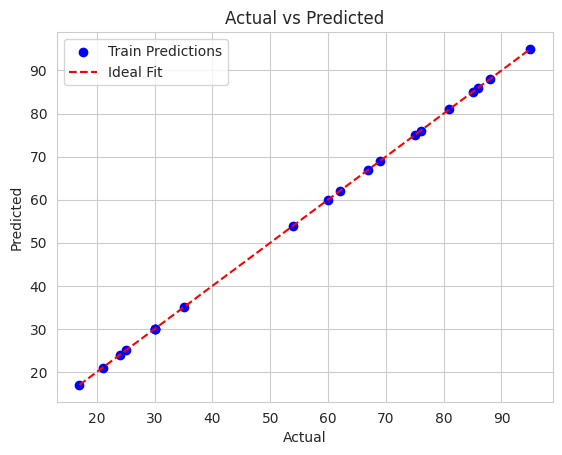

In [36]:
plt.scatter(y_train, y_train_pred, color='blue', label='Train Predictions')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='r', linestyle='--', label='Ideal Fit')

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

In [32]:
from sklearn.metrics import r2_score

# Calculate and print evaluation metrics
test_score = r2_score(y_test, y_test_pred)
print(f"Score on validation set: {test_score*100:.2f}%")

Score on validation set: 100.00%


In [31]:
train_score = r2_score(y_train, y_train_pred)
print(f"Score on train set: {train_score*100:.2f}%")

Score on train set: 100.00%


<Axes: xlabel='Scores'>

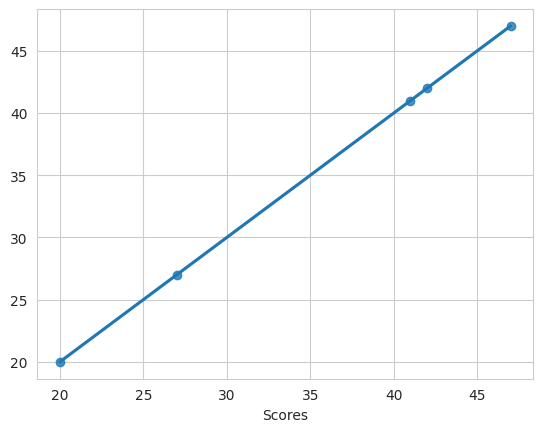

In [ ]:
# Plotting regression plot for test set
sns.regplot(x=y_test, y=y_test_pred, ci=None)